# Spliced and unspliced analysis

In [113]:
# 1) generate bam file

In [114]:
# 2) generate loom file
#velocyto run -b cellranger/run_count_K3B/outs/filtered_feature_bc_matrix/barcodes.tsv.gz -o velocyto ~/drive/bioinformatics/data_analysis/SHM_in_the_act/rna_velocity/cellranger/run_count_K3B/outs/possorted_genome_bam.bam cellranger/refdata-gex-GRCh38-2020-A/genes/genes_IGV.gtf

In [115]:
# 3) Concatenate loom files

### Read loom file

In [116]:
options(warn=-1)
library(anndata)
library(dplyr)
library(tidyr)
library("tidyverse")
library("ComplexHeatmap")

In [117]:
suppressMessages(source("code/functions.R"))

In [118]:
# read loom file, (this has to be concatenatee by python)
KB123 <- read_h5ad('rna_velocity/KB123_BCR.h5ad')

In [119]:
KB123

AnnData object with n_obs × n_vars = 17892 × 17430
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'source', 'subject', 'status', 'isSinglet', 'isDoublet', 'cellSCSM', 'sample_batch', 'batch', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
    obsp: 'distances'

In [120]:
#KB123$layers[["spliced"]]

In [121]:
#colnames(KB123$layers[["spliced"]]) #length

In [122]:
# chain expected (all)
vh_genes =  c("IGHV3-30","IGHV3-33","IGHV3-15","IGHV3-11","IGHV3-66","IGHV3-23","IGHV3-16","IGHV3-43","IGHV4-39","IGHV3-48","IGHV4-34","IGHV4-4","IGHV3-21","IGHV5-51",
             "IGHV1-69D","IGHV1-24","IGHV1-58","IGHV1-46","IGHV4-28","IGHV1-69","IGHV3-53","IGHV3/OR16-10","IGHV5-10-1","IGHV3-20","IGHV2-70","IGHV3-13","IGHV1-3","IGHV6-1",
             "IGHV1-18","IGHV3-64","IGHV3-49","IGHV4-59","IGHV4-61","IGHV2-26","IGHV1-8","IGHV3/OR16-8","IGHV1-2","IGHV4-30-2","IGHV2-70D")
vl_genes =  c("IGKV3-20","IGKV1-17","IGLV1-40","IGKV3-7","IGKV3-11","IGLV5-45","IGKV3/OR2-268","IGLV2-11","IGKV3D-20","IGKV3-15",
             "IGKV2-18","IGKV1D-17","IGKV1/OR2-108","IGLV2-14","IGLV3-19","IGKV4-1","IGLV3-21","IGLV3-1","IGKV1D-8","IGLV3-25","IGLV1-47","IGLV4-69","IGLV1-50","IGLV1-36","IGLV1-44",
             "IGKV1-33","IGKV1-8","IGKV1-12","IGKV2-28","IGLV2-8","IGLV2-23","IGLV7-43","IGLV10-54","IGLV9-49","IGKV1-9","IGKV1D-39","IGKV1-5","IGKV1-39","IGKV2-30",
             "IGKV1-27","IGLV3-27","IGKV3D-11","IGLV1-51","IGKV1D-33")

In [123]:
# chain expected  (filter)
all_genes =  c("IGHV3-30","IGHV3-33","IGHV3-15","IGHV3-11","IGHV3-66","IGHV3-23","IGHV3-43","IGHV4-39","IGHV3-48","IGHV4-34","IGHV4-4","IGHV3-21","IGHV5-51",
              "IGHV1-69D","IGHV1-24","IGHV1-58","IGHV1-46","IGHV4-28","IGHV1-69","IGHV3-53","IGHV5-10-1","IGHV3-20","IGHV2-70","IGHV3-13","IGHV1-3","IGHV6-1", 
             "IGHV1-18","IGHV3-64","IGHV3-49","IGHV4-59","IGHV4-61","IGHV2-26", #,"IGHV3/OR16-8" #"IGHV3-16","IGHV1-8"
             "IGKV3-20","IGKV1-17","IGLV1-40","IGKV3-7","IGKV3-11","IGLV5-45","IGLV2-11","IGKV3D-20","IGKV3-15", #"IGKV3/OR2-268",,"IGKV1/OR2-108","IGKV1-33","IGKV1-12","IGKV2-28","IGLV3-27","IGKV1D-33"
             "IGKV2-18","IGKV1D-17","IGLV2-14","IGLV3-19","IGKV4-1","IGLV3-21","IGLV3-1","IGKV1D-8","IGLV3-25","IGLV1-47","IGLV4-69","IGLV1-50","IGLV1-36","IGLV1-44",
             "IGKV1-8","IGLV2-8","IGLV2-23","IGLV7-43","IGLV10-54","IGLV9-49","IGKV1-9","IGKV1D-39","IGKV1-5","IGKV1-39","IGKV2-30",
             "IGKV1-27","IGKV3D-11","IGLV1-51")

In [124]:
# barcodes cell scSHM(+)
barcodes = c('TTAGGCAGTCGAACAG','AACTCTTGTGCAACTT','CATCAGAAGCGAAGGG','GCACATATCTCTAGGA','CGATCGGAGCTACCTA','AACTCAGCATTCGACA','AGTGTCACAGCTGGCT','TTATGCTCATCCTTGC','AGTGAGGGTCGATTGT','GATGCTATCTTCCTTC',
            'ACACCCTCACACCGCA','ACGCAGCAGCAGGCTA','ACGCCAGAGGCATTGG','CACACCTGTTGTGGAG','ACTGTCCCAGCTGGCT','ATCATGGGTGGTCTCG','GCACATATCGCTTAGA','AGGTCATCAGTTCCCT','ATGAGGGGTGTATGGG','CAACCAAAGTTACGGG',
            'CAACCTCGTCTGATTG','CAAGAAAAGTCCGGTC','CAAGTTGCAGCTGTGC','CACAGTACAGGATCGA','CACATAGTCATACGGT','CAGCGACCACAGCGTC','CCAATCCTCGGAAATA','CCACTACTCAGTTTGG','CCTACCATCATGCATG','GATCTAGTCGCCGTGA',
            'CCTTCCCTCTCGCATC','GTAGGCCTCTGAGTGT','GGAATAAGTCTCTCGT','GGCCGATAGATTACCC','GTCACAACAACGATCT','TCTTTCCGTCTAGTCA','TGCTGCTGTACAGTGG','TGTGGTAAGGCGACAT','TTATGCTCACACCGAC','TTTCCTCCACTTAAGC',
            'ATAACGCCAAGCCGCT','TAAACCGAGGATGGTC','GTAACTGCAATCCAAC','CCACTACGTTAAGTAG','CAAGAAAGTCTCCACT','CGGACTGAGCTGAAAT','GAGCAGATCTAACTGG','GTTCTCGCAAGCTGAG','GATCAGTAGTAACCCT','TACCTATAGCGATCCC',
            'AACTCAGCAAATCCGT','AACTCCCAGATATACG','CACCAGGGTTCGCTAA','CCATGTCCACCAGGCT','CGGCTAGTCCTTGACC','GAGGTGAAGTGGACGT','TGGCTGGGTAGTAGTA','TACCTATAGGTTCCTA','AAATGCCTCTGAAAGA','GTGTTAGAGGGAACGG',
            'GATCGTATCCCATTTA','AACACGTAGCCACCTG','AGCGTATTCTGAAAGA','AACTCCCAGCGATATA','CGCGGTATCAGGCAAG','GGCTGGTTCCCACTTG','ATTGGACCACACCGCA','TAAGAGATCAAACCGT','CACCACTAGCCTCGTG','TGTTCCGTCGGCGCAT',
            'CGACCTTGTTCCAACA')

In [125]:
length(barcodes)

[1] 71

In [126]:
# filter loom file by chian and cell barcodes
mu_shm_Ms <- KB123$layers[["spliced"]][barcodes,]
# convert to df
mu_shm_Ms <- as.data.frame(as.matrix(mu_shm_Ms)) %>% select(matches("^IG[HKL][V]"))

In [127]:
# filter loom file by chian and cell barcodes
mu_shm_Mu <- KB123$layers[["unspliced"]][barcodes,]
# convert to df
mu_shm_Mu <- as.data.frame(as.matrix(mu_shm_Mu)) %>% select(matches("^IG[HKL][V]"))

In [128]:
# convert to longer format and join 2 df
mu_shm_Ms_fil <- mu_shm_Ms %>% #filter_all(any_vars(. > 0)) %>% 
rownames_to_column("cell") %>% 
pivot_longer(!cell,names_to="chain", values_to="spliced") %>%
filter(spliced > 0) 

mu_shm_Mu_fil <- mu_shm_Mu %>% #filter_all(any_vars(. > 0)) %>% 
rownames_to_column("cell") %>% 
pivot_longer(!cell,names_to="chain", values_to="unspliced") %>%
filter(unspliced > 0) 

# join two dataframes spliced/unspliced
mu_shm_Mx_fil <- mu_shm_Ms_fil %>% 
                full_join(mu_shm_Mu_fil, by=c("cell","chain")) %>%
                mutate(type=if_else(grepl("IGH",chain), "H", "L")) %>%
                replace(is.na(.), 0)  %>% group_by(cell,type) %>% 
  summarize(spliced =sum(spliced),unspliced =sum(unspliced))  #summarize by cell a chan type

`summarise()` has grouped output by 'cell'. You can override using the `.groups` argument.


In [129]:
head(mu_shm_Mx_fil)

cell,type,spliced,unspliced
<chr>,<chr>,<dbl>,<dbl>
AAATGCCTCTGAAAGA,H,82,0
AAATGCCTCTGAAAGA,L,2,71
AACACGTAGCCACCTG,H,11,0
AACACGTAGCCACCTG,L,4,35
AACTCAGCAAATCCGT,H,54,1
AACTCAGCAAATCCGT,L,9,67


In [130]:
# scSHM until filter 4
df <- read.csv("output/df_summary.csv") %>% mutate(sample=gsub(".{3}$", "", subject))
head(df)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive,sample
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>
1,K1B_S10000-LC,TTAGGCAGTCGAACAG,10,C,TG.TG,FR1,C-T,5-8,TRUE,K1B_S10000
2,K1B_S12282-LC,AACTCTTGTGCAACTT,9,G,GT.TT,FR1,A-C,14-9,TRUE,K1B_S12282
3,K1B_S12282-LC,AACTCTTGTGCAACTT,89,G,TA.CA,CDR1,C-G,7-11,TRUE,K1B_S12282
4,K1B_S144-LC,TTTCCTCCACTTAAGC,4,A,AC.TC,FR1,A-G,6-7,TRUE,K1B_S144
5,K1B_S144-LC,ATCATGGGTGGTCTCG,4,A,AC.TC,FR1,A-T,12-22,TRUE,K1B_S144
6,K1B_S144-LC,TTTCCTCCACTTAAGC,8,A,CC.GA,FR1,A-G,6-7,TRUE,K1B_S144


In [131]:
# join two dataframes spliced/unspliced
mu_shm <- df%>%
          full_join(mu_shm_Mx_fil, by=c("cell"))  %>%
          mutate(shm_gene=str_extract(subject, "[^-]+$")) 
                

head(mu_shm)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive,sample,type,spliced,unspliced,shm_gene
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,K1B_S10000-LC,TTAGGCAGTCGAACAG,10,C,TG.TG,FR1,C-T,5-8,TRUE,K1B_S10000,H,3,0,LC
2,K1B_S10000-LC,TTAGGCAGTCGAACAG,10,C,TG.TG,FR1,C-T,5-8,TRUE,K1B_S10000,L,8,5,LC
3,K1B_S12282-LC,AACTCTTGTGCAACTT,9,G,GT.TT,FR1,A-C,14-9,TRUE,K1B_S12282,H,3,0,LC
4,K1B_S12282-LC,AACTCTTGTGCAACTT,9,G,GT.TT,FR1,A-C,14-9,TRUE,K1B_S12282,L,11,23,LC
5,K1B_S12282-LC,AACTCTTGTGCAACTT,89,G,TA.CA,CDR1,C-G,7-11,TRUE,K1B_S12282,H,3,0,LC
6,K1B_S12282-LC,AACTCTTGTGCAACTT,89,G,TA.CA,CDR1,C-G,7-11,TRUE,K1B_S12282,L,11,23,LC


In [132]:
mu_shm_perc <- mu_shm %>%  dplyr::group_by(cell, type, spliced, unspliced) %>%
          dplyr::summarise(shm_gene = paste(shm_gene, collapse = "-")) %>% 
          pivot_longer(-c(cell,type, shm_gene), "status","umi_number") %>%
          group_by(cell,type) %>% unique() %>% mutate(Perc_spl =value * 100 / sum(value)) 

head(mu_shm_perc)

`summarise()` has grouped output by 'cell', 'type', 'spliced'. You can override using the `.groups`
argument.


cell,type,shm_gene,status,value,Perc_spl
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
AAATGCCTCTGAAAGA,H,LC,spliced,82,100.000000
AAATGCCTCTGAAAGA,H,LC,unspliced,0,0.000000
AAATGCCTCTGAAAGA,L,LC,spliced,2,2.739726
AAATGCCTCTGAAAGA,L,LC,unspliced,71,97.260274
AACACGTAGCCACCTG,H,LC,spliced,11,100.000000
AACACGTAGCCACCTG,H,LC,unspliced,0,0.000000


In [133]:
mu_shm_perc %>% pull(cell) %>% unique() %>% length()

[1] 71

In [134]:
mu_shm_perc_neg <- mu_shm_perc %>%
                   mutate(value=if_else(type == "L", -(value),value)) %>%
                   mutate(Perc_spl=if_else(type == "L", -(Perc_spl),Perc_spl)) 

head(mu_shm_perc_neg)

cell,type,shm_gene,status,value,Perc_spl
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
AAATGCCTCTGAAAGA,H,LC,spliced,82,100.000000
AAATGCCTCTGAAAGA,H,LC,unspliced,0,0.000000
AAATGCCTCTGAAAGA,L,LC,spliced,-2,-2.739726
AAATGCCTCTGAAAGA,L,LC,unspliced,-71,-97.260274
AACACGTAGCCACCTG,H,LC,spliced,11,100.000000
AACACGTAGCCACCTG,H,LC,unspliced,0,0.000000


In [135]:
#define gene order for plotting
cell_order <- mu_shm_perc %>% filter(type == "H") %>% arrange(-Perc_spl) %>% pull(cell) %>% unique() 

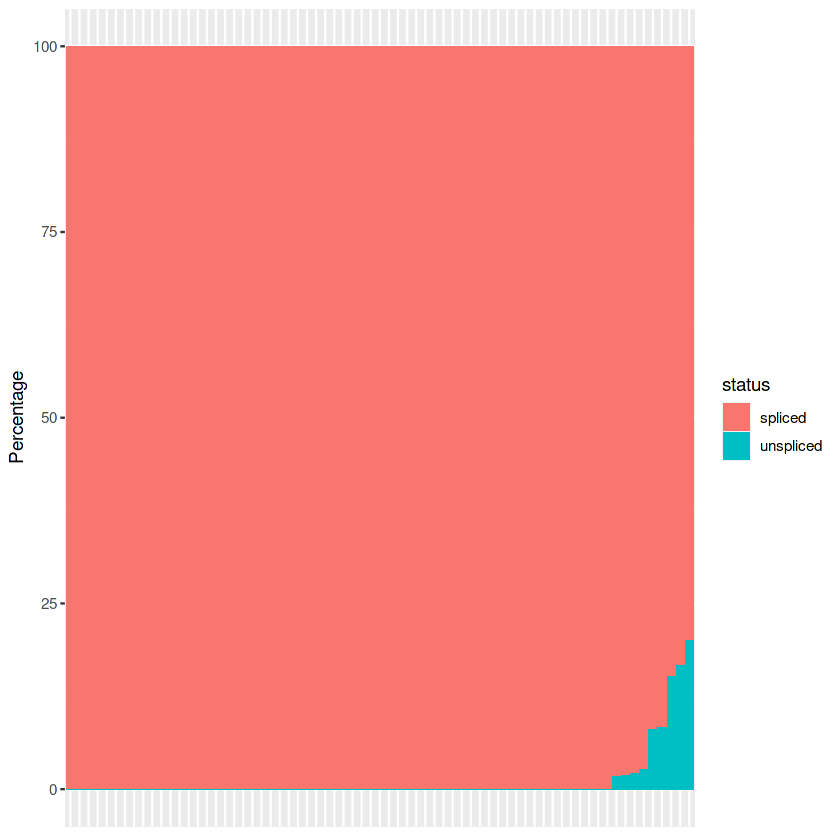

In [136]:
# Stacked barplot with multiple groups
intron_plot <- mu_shm_perc %>% filter(type == "H") %>% mutate(cell = factor(cell, levels = cell_order)) %>%
 ggplot(aes(x=cell, y=Perc_spl, fill=status)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()) +
   ylab("Percentage")

intron_plot

#fig_save(intron_plot, filename ="figs/FL/intron_cell", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

In [137]:
#define gene order for plotting
cell_order_L <- mu_shm_perc %>%filter(type == "L", status =="unspliced")  %>% arrange(-Perc_spl) %>% pull(cell) %>% unique() 

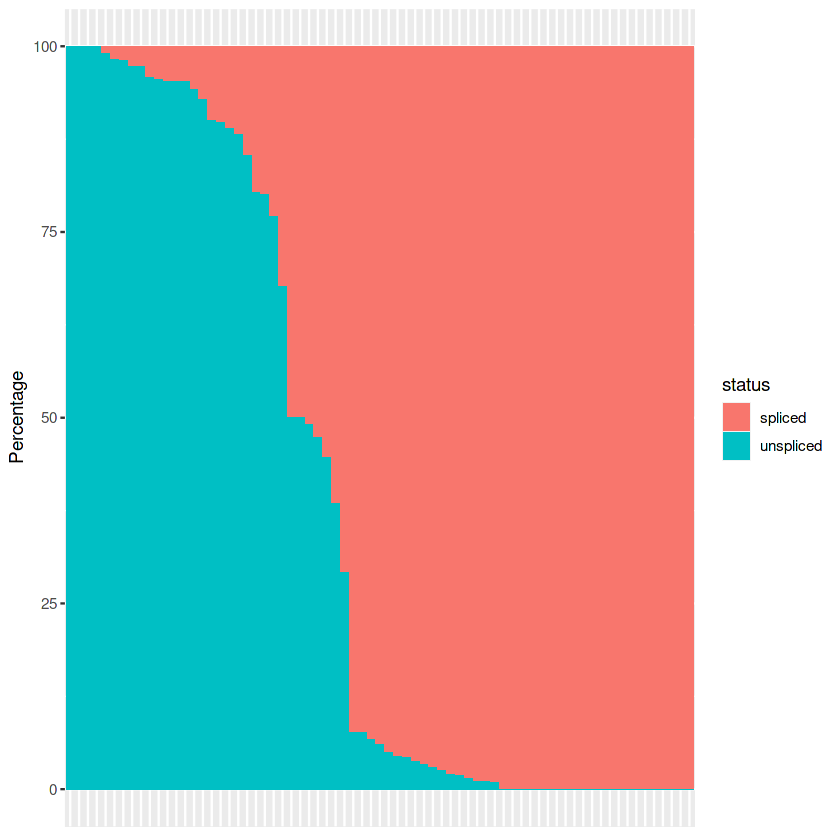

In [138]:
# Stacked barplot with multiple groups
intron_plot <- mu_shm_perc %>% filter(type == "L") %>% mutate(cell = factor(cell, levels = cell_order_L)) %>%
 ggplot(aes(x=cell, y=Perc_spl, fill=status)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()) +
   ylab("Percentage")

intron_plot

In [139]:
#define gene order for plotting
cell_order <- mu_shm_perc %>%filter(type == "L")  %>% arrange(-value) %>% pull(cell) %>% unique() 

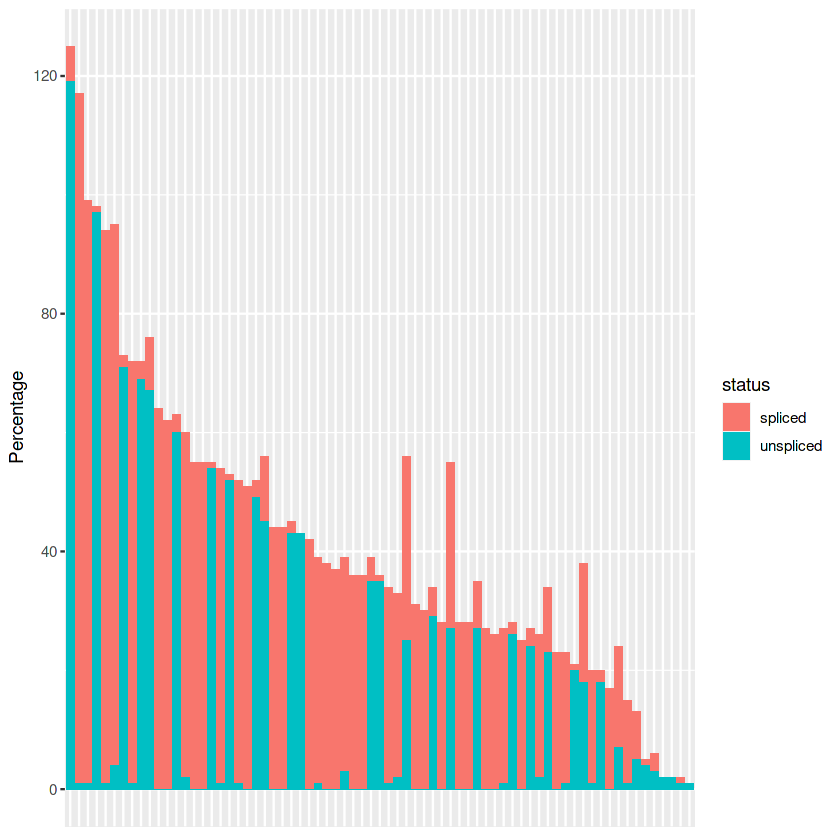

In [140]:
# Stacked barplot with multiple groups
intron_plot <- mu_shm_perc %>% filter(type == "L") %>% #mutate(cell = factor(cell, levels = cell_order)) %>%
 ggplot(aes(x=factor(cell, levels = cell_order), y=value, fill=status)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()) +
   ylab("Percentage")

intron_plot

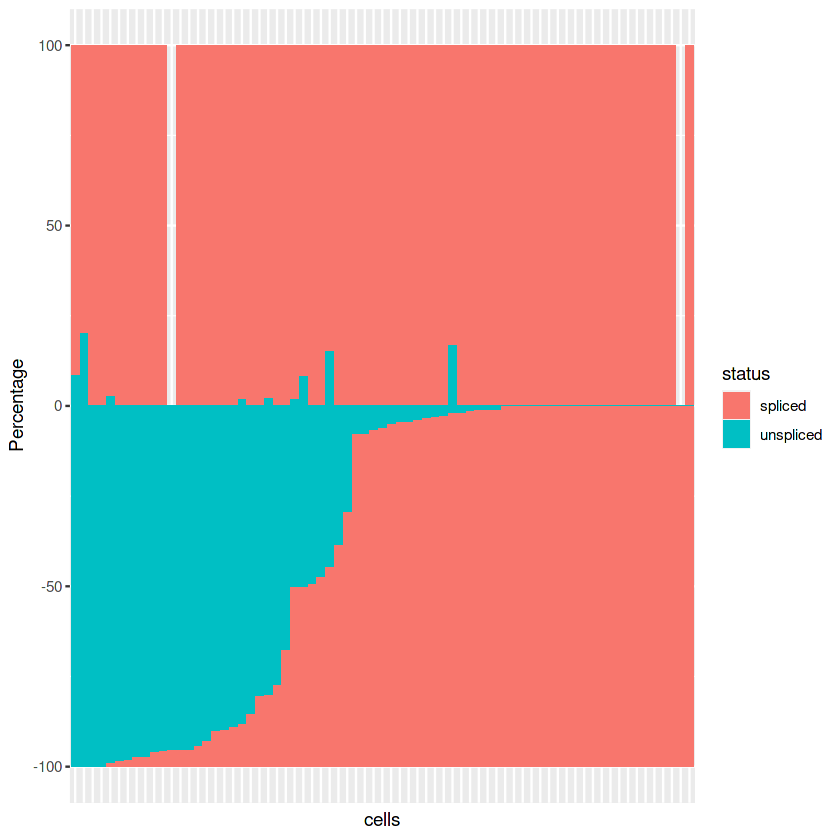

In [141]:
# Stacked barplot with multiple groups
intron_plot <- mu_shm_perc_neg  %>% mutate(cell = factor(cell, levels = cell_order_L)) %>%
 ggplot(aes(x=cell, y=Perc_spl, fill=status)) +
  geom_bar(stat="identity") +
  theme(
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()) +
   ylab("Percentage") + xlab("cells")

intron_plot

fig_save(intron_plot, filename ="figs/FL/spliced_cell_perc", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

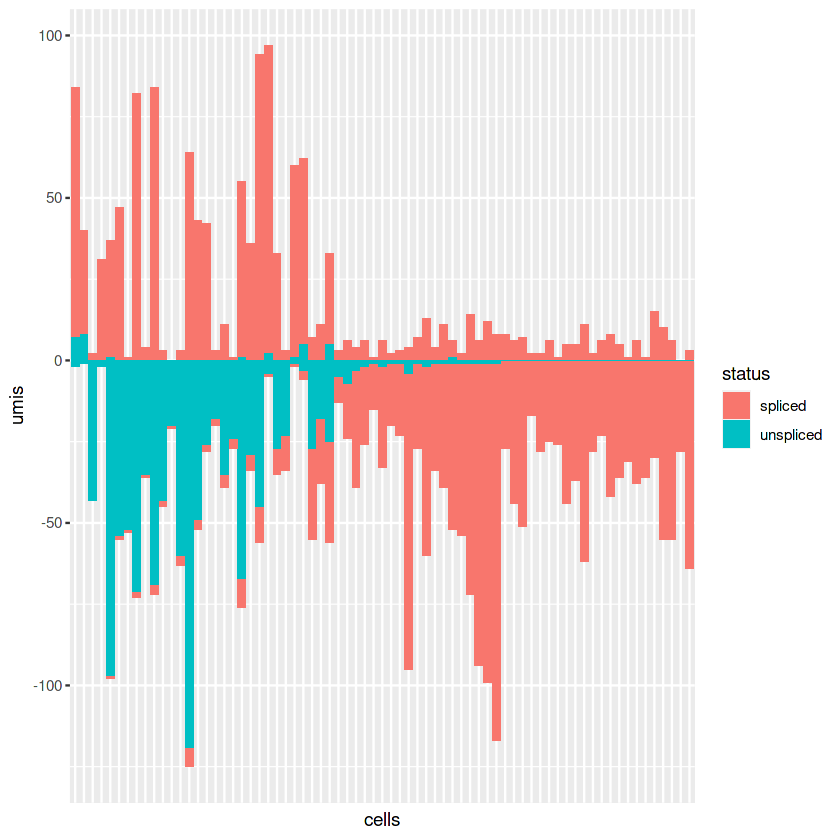

In [142]:
# Stacked barplot with multiple groups
intron_plot <- mu_shm_perc_neg  %>% mutate(cell = factor(cell, levels = cell_order_L)) %>%
 ggplot(aes(x=cell, y=value, fill=status)) +
  geom_bar(stat="identity") +
  theme(
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()) +
   ylab("umis") + xlab("cells") #+
#   geom_text(aes(label =shm_gene) , size = 3, vjust=-0.5)

intron_plot

fig_save(intron_plot, filename ="figs/FL/spliced_cell_value", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

In [143]:
mu_shm_perc_neg_plot <- mu_shm_perc_neg %>% mutate(value = 1)

In [144]:
cols <- c('LC'='green', 'HC-HC'='red','HC'='red','LC-LC'='green','LC-LC-LC-LC'='green','LC-LC-LC-LC-LC'='green','HC-HC-HC-LC'='orange','LC-LC-LC'='green','HC-LC'='orange','HC-HC-LC'='orange')

In [145]:
mu_shm_perc_neg_plot %>% filter(shm_gene == 'LC-LC-LC-LC')

cell,type,shm_gene,status,value,Perc_spl
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
AGTGTCACAGCTGGCT,H,LC-LC-LC-LC,spliced,1,100.0
AGTGTCACAGCTGGCT,H,LC-LC-LC-LC,unspliced,1,0.0
AGTGTCACAGCTGGCT,L,LC-LC-LC-LC,spliced,1,-100.0
AGTGTCACAGCTGGCT,L,LC-LC-LC-LC,unspliced,1,0.0
GTGTTAGAGGGAACGG,H,LC-LC-LC-LC,spliced,1,100.0
GTGTTAGAGGGAACGG,H,LC-LC-LC-LC,unspliced,1,0.0
GTGTTAGAGGGAACGG,L,LC-LC-LC-LC,spliced,1,-4.8
GTGTTAGAGGGAACGG,L,LC-LC-LC-LC,unspliced,1,-95.2


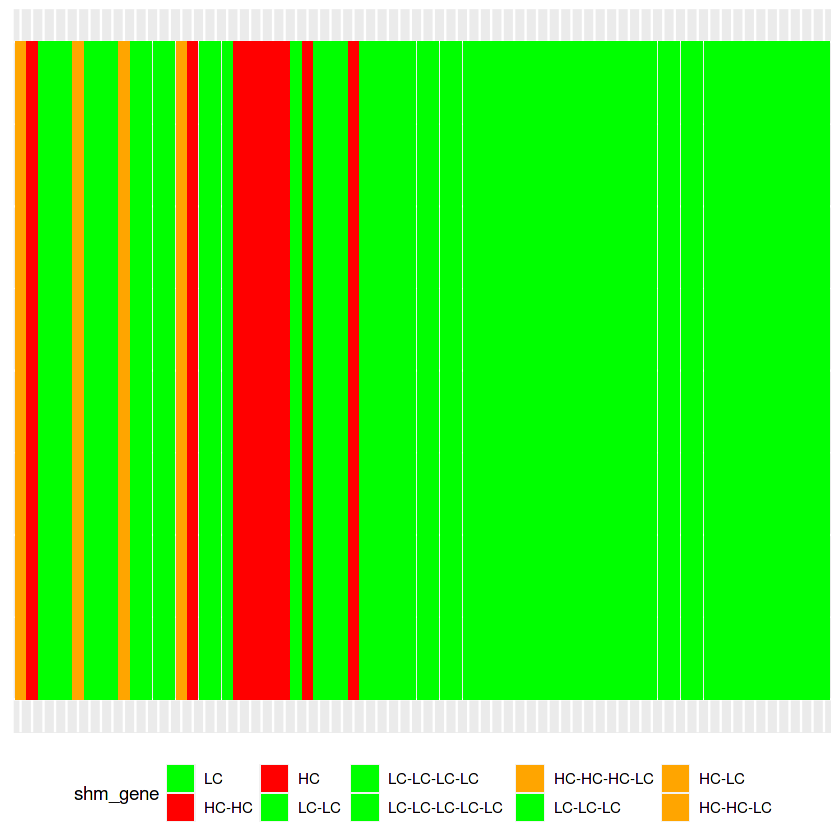

In [146]:
# Stacked barplot with multiple groups
intron_plot_t <- mu_shm_perc_neg_plot %>% filter(type == "L") %>% mutate(cell = factor(cell, levels = cell_order_L)) %>%
 ggplot(aes(x=cell, y=value,fill=shm_gene)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
       legend.position="bottom") +
   ylab("Percentage") +
   scale_fill_manual(values = cols)

intron_plot_t

fig_save(intron_plot_t, filename ="figs/FL/annotation_bar", formats = c("pdf", "png"), width = 17, height =3, units = "cm", dpi = 320)

## Heatmap

In [147]:
mu_shm_perc_matrix <- mu_shm_perc %>% ungroup() %>% mutate(gene=paste0(type,"_",status)) %>% 
select(cell,gene,value) %>% pivot_wider(cell, names_from=gene, values_from=value) %>% column_to_rownames(var="cell") %>%
replace(is.na(.), 0)

head(mu_shm_perc_matrix)

,H_spliced,H_unspliced,L_spliced,L_unspliced
,<dbl>,<dbl>,<dbl>,<dbl>
AAATGCCTCTGAAAGA,82,0,2,71
AACACGTAGCCACCTG,11,0,4,35
AACTCAGCAAATCCGT,54,1,9,67
AACTCAGCATTCGACA,6,0,31,2
AACTCCCAGATATACG,33,0,8,27
AACTCCCAGCGATATA,3,0,2,43


In [148]:
col_fun = circlize::colorRamp2(c(0,75,150), c("grey96","green","red"))

    
png(file="figs/FL/heatmap_spliced_IG_genes.png",width=5,height=15,units="cm",res=300)
Heatmap(mu_shm_perc_matrix, 
        cluster_rows= FALSE,cluster_columns= FALSE, #column_km= 3,
        row_dend_reorder= TRUE,
        name = "umis",#title of legend 
        column_title = "gene_status", column_title_side="bottom",row_title = "Cells", #split = mu_shm_perc_matrix$L_unspliced,
        row_names_gp = gpar(fontsize = 3), # Text size for row names
        column_names_gp = gpar(fontsize = 9),
        col= col_fun #(rainbow(10)),
#         rect_gp=gpar(col="white", lwd=2)
       )
dev.off()

png 
  2

In [84]:
# load gtf and convert to df
#gtf <- rtracklayer::import('rna_velocity//cellranger/refdata-gex-GRCh38-2020-A//genes/genes.gtf')
#gtf_df=as.data.frame(gtf)

In [85]:
# filter df for IGV genes and export as gtf
#gtf_IGV <- gtf_df %>% filter(transcript_type == "IG_V_gene")#filter(grepl("^IGH", transcript_name))
#rtracklayer::export(gtf_IGV, "rna_velocity//cellranger/refdata-gex-GRCh38-2020-A//genes/gtf_IGV.gtf")

## Spliced/unspliced analysis in scSHM(-)

In [86]:
# filter loom file by chian and cell barcodes
mu_shm_Ms <- KB123$layers[["spliced"]][200:270,]
# convert to df
mu_shm_Ms <- as.data.frame(as.matrix(mu_shm_Ms)) %>% select(matches("^IG[HKL][V]"))

In [87]:
# filter loom file by chian and cell barcodes
mu_shm_Mu <- KB123$layers[["unspliced"]][200:270,]
# convert to df
mu_shm_Mu <- as.data.frame(as.matrix(mu_shm_Mu)) %>% select(matches("^IG[HKL][V]"))

In [88]:
# convert to longer format and join 2 df
mu_shm_Ms_fil <- mu_shm_Ms %>% #filter_all(any_vars(. > 0)) %>% 
rownames_to_column("cell") %>% 
pivot_longer(!cell,names_to="chain", values_to="spliced") %>%
filter(spliced > 0) 

mu_shm_Mu_fil <- mu_shm_Mu %>% #filter_all(any_vars(. > 0)) %>% 
rownames_to_column("cell") %>% 
pivot_longer(!cell,names_to="chain", values_to="unspliced") %>%
filter(unspliced > 0) 

# join two dataframes spliced/unspliced
mu_shm_Ms_fil <- mu_shm_Ms_fil %>% 
                full_join(mu_shm_Mu_fil, by=c("cell","chain")) %>%
                mutate(type=if_else(grepl("IGH",chain), "H", "L")) %>%
                replace(is.na(.), 0)  %>% group_by(cell,type) %>% 
  summarize(spliced =sum(spliced),unspliced =sum(unspliced))  #summarize by cell a chan type

`summarise()` has grouped output by 'cell'. You can override using the `.groups` argument.


In [89]:
head(mu_shm_Ms_fil)

cell,type,spliced,unspliced
<chr>,<chr>,<dbl>,<dbl>
AAGGTTCAGGGCTTCC,H,1,0
AAGGTTCAGGGCTTCC,L,8,6
AAGGTTCAGTTCGATC,H,1,0
AAGGTTCAGTTCGATC,L,24,11
AAGGTTCCATCCAACA,H,3,0
AAGGTTCCATCCAACA,L,6,2


In [90]:
mu_shm_perc <- mu_shm_Ms_fil %>% select(cell, type, spliced, unspliced) %>% pivot_longer(-c(cell,type), "status","umi_number") %>%
group_by(cell,type) %>%  unique() %>% mutate(Perc_spl =value * 100 / sum(value)) 

head(mu_shm_perc)

cell,type,status,value,Perc_spl
<chr>,<chr>,<chr>,<dbl>,<dbl>
AAGGTTCAGGGCTTCC,H,spliced,1,100.00000
AAGGTTCAGGGCTTCC,H,unspliced,0,0.00000
AAGGTTCAGGGCTTCC,L,spliced,8,57.14286
AAGGTTCAGGGCTTCC,L,unspliced,6,42.85714
AAGGTTCAGTTCGATC,H,spliced,1,100.00000
AAGGTTCAGTTCGATC,H,unspliced,0,0.00000


In [91]:
mu_shm_perc_neg <- mu_shm_perc %>%
                   mutate(value=if_else(type == "L", -(value),value)) %>%
                   mutate(Perc_spl=if_else(type == "L", -(Perc_spl),Perc_spl)) 

head(mu_shm_perc_neg)

cell,type,status,value,Perc_spl
<chr>,<chr>,<chr>,<dbl>,<dbl>
AAGGTTCAGGGCTTCC,H,spliced,1,100.00000
AAGGTTCAGGGCTTCC,H,unspliced,0,0.00000
AAGGTTCAGGGCTTCC,L,spliced,-8,-57.14286
AAGGTTCAGGGCTTCC,L,unspliced,-6,-42.85714
AAGGTTCAGTTCGATC,H,spliced,1,100.00000
AAGGTTCAGTTCGATC,H,unspliced,0,0.00000


In [92]:
#define gene order for plotting
cell_order <- mu_shm_perc %>% filter(type == "H") %>% arrange(-Perc_spl) %>% pull(cell) %>% unique() 

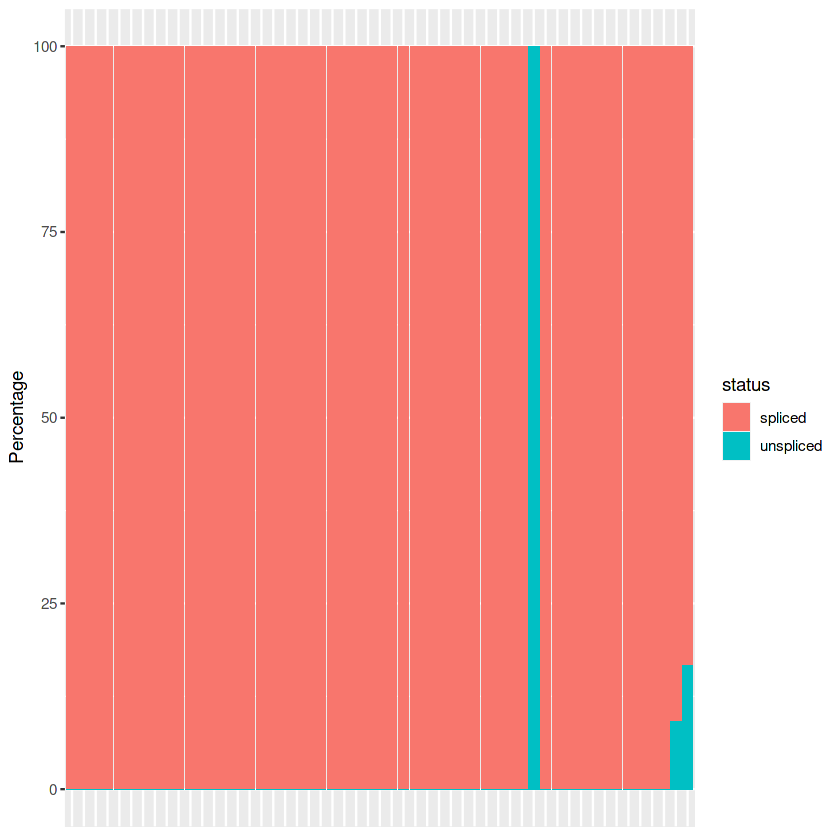

In [93]:
# Stacked barplot with multiple groups
intron_plot <- mu_shm_perc %>% filter(type == "H") %>% mutate(cell = factor(cell, levels = cell_order)) %>%
 ggplot(aes(x=cell, y=Perc_spl, fill=status)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()) +
   ylab("Percentage")

intron_plot

#fig_save(intron_plot, filename ="figs/FL/intron_cell", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

In [94]:
#define gene order for plotting
cell_order_L <- mu_shm_perc %>%filter(type == "L", status =="unspliced")  %>% arrange(-Perc_spl) %>% pull(cell) %>% unique() 

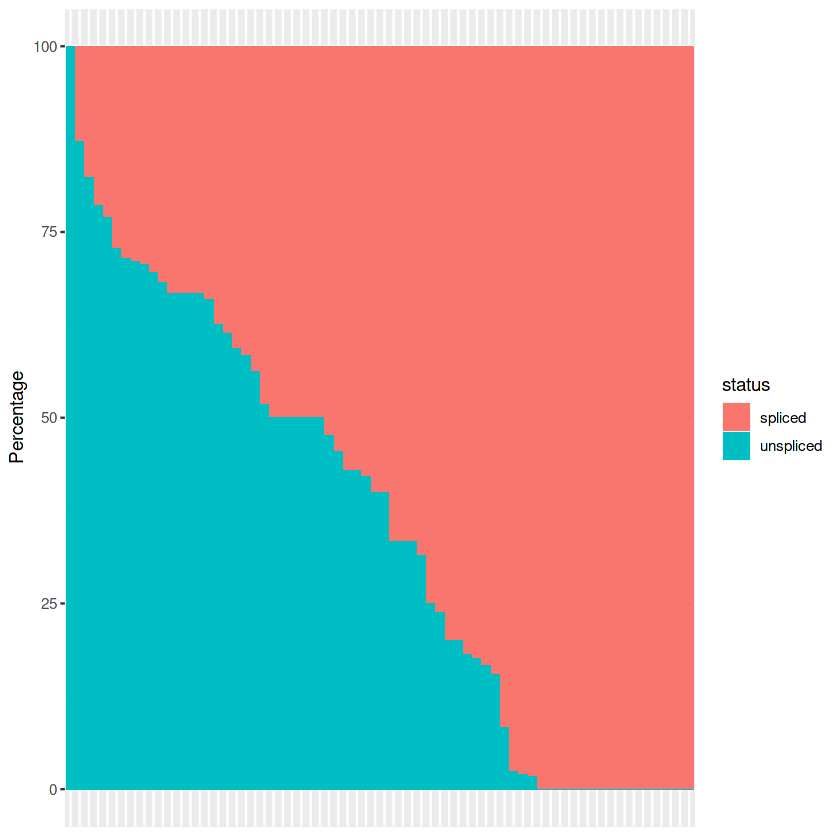

In [95]:
# Stacked barplot with multiple groups
intron_plot <- mu_shm_perc %>% filter(type == "L") %>% mutate(cell = factor(cell, levels = cell_order_L)) %>%
 ggplot(aes(x=cell, y=Perc_spl, fill=status)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()) +
   ylab("Percentage")

intron_plot

In [96]:
#define gene order for plotting
cell_order <- mu_shm_perc %>%filter(type == "L")  %>% arrange(-value) %>% pull(cell) %>% unique() 

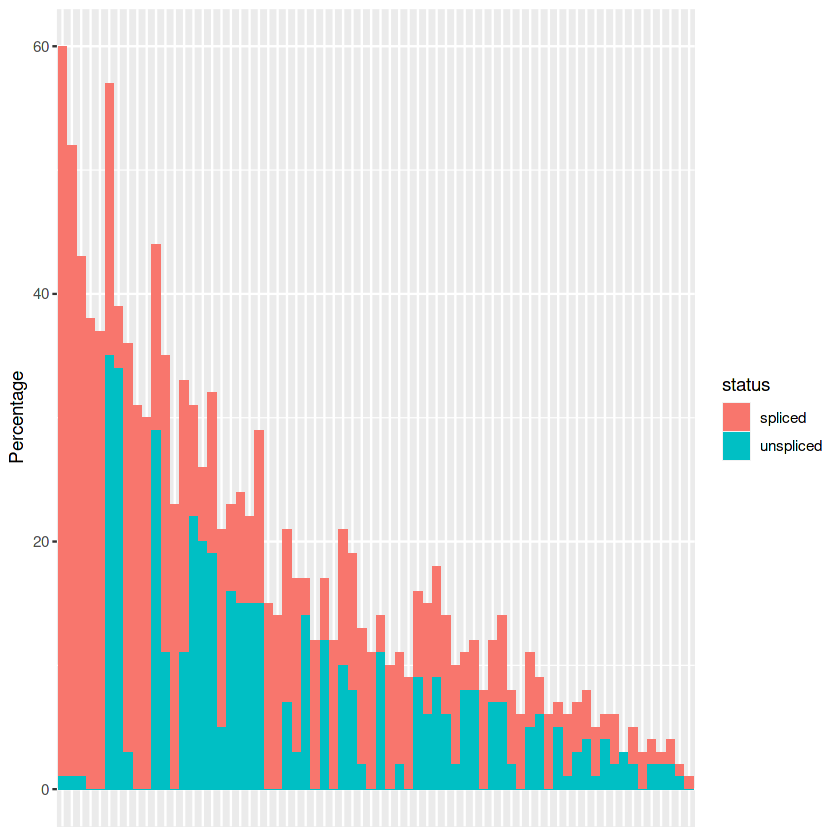

In [97]:
# Stacked barplot with multiple groups
intron_plot <- mu_shm_perc %>% filter(type == "L") %>% #mutate(cell = factor(cell, levels = cell_order)) %>%
 ggplot(aes(x=factor(cell, levels = cell_order), y=value, fill=status)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()) +
   ylab("Percentage")

intron_plot

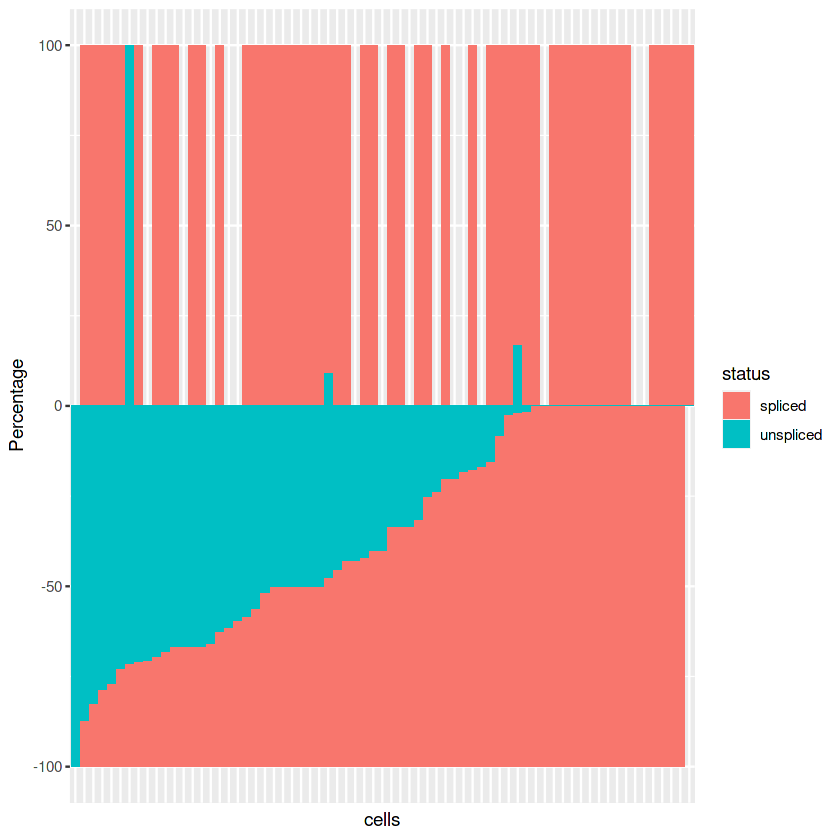

In [98]:
# Stacked barplot with multiple groups
intron_plot <- mu_shm_perc_neg  %>% mutate(cell = factor(cell, levels = cell_order_L)) %>%
 ggplot(aes(x=cell, y=Perc_spl, fill=status)) +
  geom_bar(stat="identity") +
  theme(
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()) +
   ylab("Percentage") + xlab("cells")

intron_plot

fig_save(intron_plot, filename ="figs/FL/spliced_cell_perc_shm_neg", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

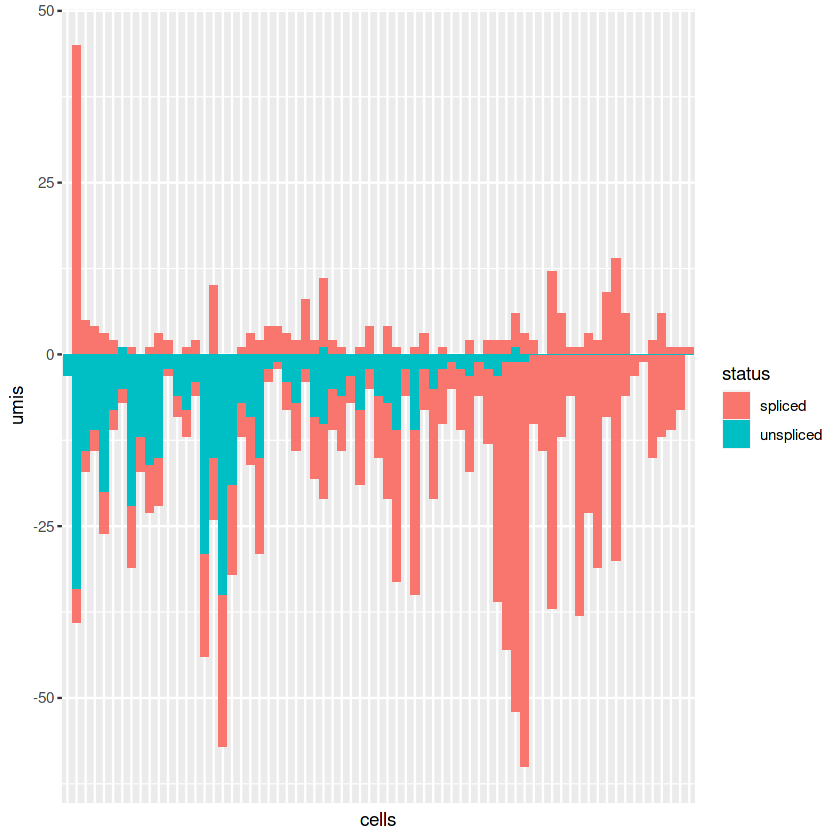

In [99]:
# Stacked barplot with multiple groups
intron_plot <- mu_shm_perc_neg  %>% mutate(cell = factor(cell, levels = cell_order_L)) %>%
 ggplot(aes(x=cell, y=value, fill=status)) +
  geom_bar(stat="identity") +
  theme(
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()) +
   ylab("umis") + xlab("cells")

intron_plot

fig_save(intron_plot, filename ="figs/FL/spliced_cell_value_shm_neg", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

## Heatmap

In [100]:
mu_shm_perc_matrix <- mu_shm_perc %>% ungroup() %>% mutate(gene=paste0(type,"_",status)) %>% 
select(cell,gene,value) %>% pivot_wider(cell, names_from=gene, values_from=value) %>% column_to_rownames(var="cell") %>%
replace(is.na(.), 0)

head(mu_shm_perc_matrix)

,H_spliced,H_unspliced,L_spliced,L_unspliced
,<dbl>,<dbl>,<dbl>,<dbl>
AAGGTTCAGGGCTTCC,1,0,8,6
AAGGTTCAGTTCGATC,1,0,24,11
AAGGTTCCATCCAACA,3,0,6,2
AAGGTTCCATTGAGCT,0,0,4,3
AAGGTTCGTTGAACTC,10,0,9,15
AAGGTTCGTTGTACAC,2,0,42,1


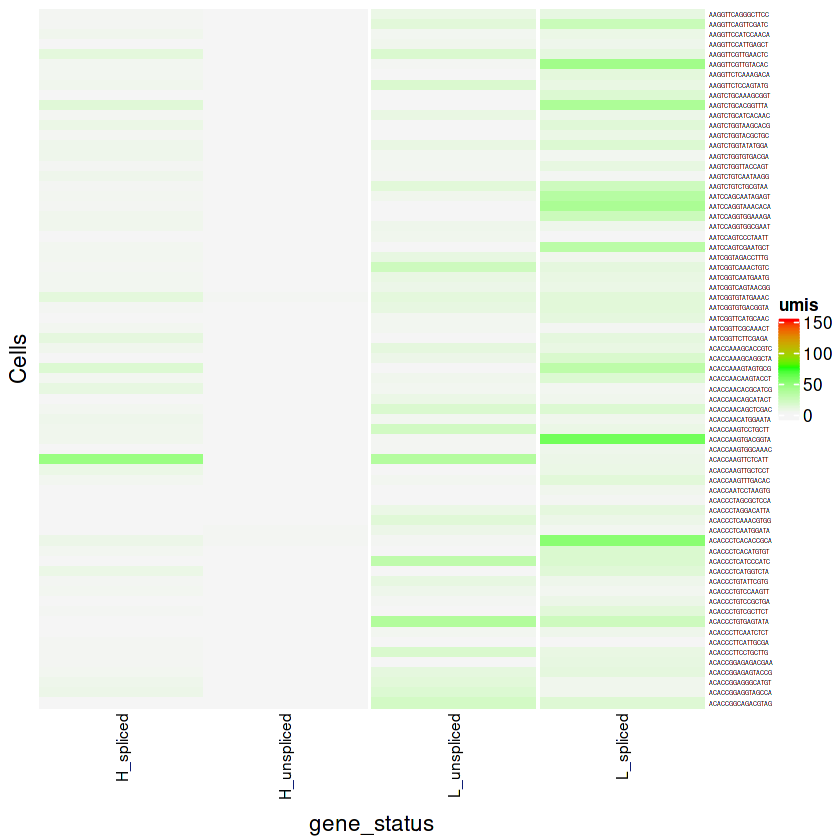

In [101]:
col_fun = circlize::colorRamp2(c(0,75,150), c("grey96","green","red"))

    
#png(file="figs/FL/heatmap_spliced_IG_genes.png",width=10,height=15,units="cm",res=300)
Heatmap(mu_shm_perc_matrix, 
        cluster_rows= FALSE,cluster_columns= FALSE, column_km= 3,
        row_dend_reorder= TRUE,
        name = "umis",#title of legend 
        column_title = "gene_status", column_title_side="bottom",row_title = "Cells", #split = mu_shm_perc_matrix$L_unspliced,
        row_names_gp = gpar(fontsize = 3), # Text size for row names
        column_names_gp = gpar(fontsize = 9),
        col= col_fun #(rainbow(10)),
#         rect_gp=gpar(col="white", lwd=2)
       )
#dev.off()

## Spliced/unspliced analysis in scSHM(+) other genes usssing GEX data

In [102]:
# read loom file, (this has to be concatenatee by python)
KB123_GEX <- read_h5ad('rna_velocity/KB123_GEX_shm_pos.h5ad')

In [103]:
KB123_GEX

AnnData object with n_obs × n_vars = 71 × 17430
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'source', 'subject', 'status', 'isSinglet', 'isDoublet', 'cellSCSM', 'sample_batch', 'batch', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_counts', 'velocity_self_transition'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'neighbors', 'seurat_clusters_colors', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap', 'velocity_pca', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'spliced', 'unspliced', 'variance_velocity', 'velocity'
    obsp: 'connectivities', 'distances'

In [104]:
# genes import for the FL pathogenesis ( full list of genes found mutated in ≥10% of cases)
# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4100800/#SD1

fl_genes <- read.csv("input/NIHMS552004-supplement-Updated_Table_S7.csv")
head(fl_genes)

fl_names <- fl_genes %>% pull(Gene) %>% unique()
fl_names

,Sample,Gene,Exon.,Strand,Genome_Change..,cDNA_Change,Protein_Change,Variant_Classification,PPH2_Class,Refseq_prot_Id,Sanger.validation,Somatic.status
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,ABCA13,18,+,g.chr7:48319056G>T,c.8265G>T,p.W2755C,Missense_Mutation,deleterious,NP_689914,Yes,somatic
2,6,ABCA13,10,+,g.chr7:48280528T>A,c.1127T>A,p.L376Q,Missense_Mutation,deleterious,NP_689914,nd,somatic
3,10,ABCA13,38,+,g.chr7:48431556C>T,c.11693C>T,p.T3898I,Missense_Mutation,deleterious,NP_689914,Yes,
4,25,ABCA13,30,+,g.chr7:48390288G>A,c.10253G>A,p.R3418H,Missense_Mutation,neutral,NP_689914,nd,
5,38,ABCA13,13,+,g.chr7:48285584A>C,c.1616A>C,p.E539A,Missense_Mutation,deleterious,NP_689914,nd,
6,48,ABCA13,17,+,g.chr7:48314670G>A,c.5407G>A,p.E1803K,Missense_Mutation,deleterious,NP_689914,nd,


[1] "ABCA13"    "ANKMY1"    "ANKS1A"    "APC2"      "ARHGEF10"  "ARID1A"   
 [7] "ARID1B"    "AUTS2"     "B2M"       "BCL2"      "BIRC6"     "BMP7"     
[13] "CACNA1H"   "CADPS"     "CARD11"    "CCND3"     "CD58"      "CD79B"    
[19] "CDKN2A"    "CREBBP"    "CSMD2"     "DCC"       "DMD"       "DSC3"     
[25] "DTX1"      "EBF1"      "EML6"      "EP300"     "EPAS1"     "EPHA7"    
[31] "EZH2"      "FAM129B"   "FAM190A"   "FAS"       "FAT4"      "FBN2"     
[37] "FBXO11"    "FLNB"      "FMN2"      "FOXO1"     "GCC2"      "GFRAL"    
[43] "GNA13"     "GNAI2"     "GRID2"     "HERC1"     "HIST1H1E"  "HIST1H2AC"
[49] "HIST1H3D"  "HNRNPU"    "IRF4"      "IRF8"      "ITPKB"     "ITPR1"    
[55] "KDM6B"     "KLHL6"     "MAST4"     "MEF2B"     "MLL2"      "MLL3"     
[61] "MLLT6"     "MYC"       "NAV3"      "NEBL"      "NOC4L"     "NOTCH1"   
[67] "NTRK1"     "OR5R1"     "PARP14"    "PAX5"      "PCDH7"     "PCLO"     
[73] "PIKFYVE"   "PIM1"      "PLD1"      "POU2AF1"   "RP1L1"     "SDK1"     
[79] "SGK1"      "SLC1A7"    "SOCS1"     "STAT6"     "SYNE1"     "SYNJ2"    
[85] "TAF1"      "TAGAP"     "TBC1D4"    "TBCD"      "TET2"      "THBS1"    
[91] "TMEM30A"   "TNFAIP3"   "TNFRSF14"  "TNIK"      "TP53"      "TYRP1"    
[97] "XIRP2"     "ZNF462"    "ZNF845"

In [105]:
fl_names_filter <- c('ANKMY1','ANKS1A','APC2','ARHGEF10','ARID1A','ARID1B','B2M','BCL2','BIRC6','BMP7','CADPS','CARD11','CCND3','CD58','CD79B','CDKN2A',
         'CREBBP','DMD','DTX1','EBF1','EML6','EP300','EPAS1','EZH2','FAS','FBXO11','FLNB','FMN2','FOXO1','GCC2','GNA13','GNAI2',
         'HERC1','HIST1H1E','HIST1H2AC','HNRNPU','IRF4','IRF8','ITPKB','ITPR1','KDM6B','KLHL6', 'MAST4','MEF2B','MLLT6',
         'MYC','NEBL','NOC4L','NOTCH1','PARP14','PAX5','PCLO','PIKFYVE','PIM1', 'POU2AF1','SDK1','SGK1',
         'SOCS1','STAT6','SYNE1','SYNJ2','TAF1','TAGAP','TBC1D4','TBCD','TET2','TMEM30A','TNFAIP3','TNFRSF14','TNIK','TP53',
         'ZNF845')

In [106]:
length(fl_names_filter)

[1] 72

In [107]:
# filter loom file by chian and cell barcodes
mu_shm_Ms <- KB123_GEX$layers[["spliced"]][barcodes,]
# convert to df
mu_shm_Ms <- as.data.frame(as.matrix(mu_shm_Ms)) %>% select_(.dots= fl_names_filter)

In [108]:
# filter loom file by chian and cell barcodes
mu_shm_Mu <- KB123_GEX$layers[["unspliced"]][barcodes,]
# convert to df
mu_shm_Mu <- as.data.frame(as.matrix(mu_shm_Mu)) %>% select_(.dots= fl_names_filter)

In [109]:
# convert to longer format and join 2 df
mu_shm_Ms_fil <- mu_shm_Ms %>% #filter_all(any_vars(. > 0)) %>% 
rownames_to_column("cell") %>% 
pivot_longer(!cell,names_to="gene", values_to="spliced") %>%
filter(spliced > 0) 

mu_shm_Mu_fil <- mu_shm_Mu %>% #filter_all(any_vars(. > 0)) %>% 
rownames_to_column("cell") %>% 
pivot_longer(!cell,names_to="gene", values_to="unspliced") %>%
filter(unspliced > 0) 

# join two dataframes spliced/unspliced
mu_shm_Mx_fil <- mu_shm_Ms_fil %>% 
                full_join(mu_shm_Mu_fil, by=c("cell","gene")) %>%
#                mutate(type=if_else(grepl("IGH",chain), "H", "L")) %>%
                 group_by(cell,gene) %>%  #replace(is.na(.), 0) 
  summarize(spliced =sum(spliced),unspliced =sum(unspliced))  #summarize by cell a chan type

`summarise()` has grouped output by 'cell'. You can override using the `.groups` argument.


## Heatmap

In [110]:
head(mu_shm_Mx_fil)

cell,gene,spliced,unspliced
<chr>,<chr>,<dbl>,<dbl>
AAATGCCTCTGAAAGA,B2M,NA,0.2768943
AAATGCCTCTGAAAGA,EBF1,NA,0.5537886
AAATGCCTCTGAAAGA,EML6,NA,0.2768943
AAATGCCTCTGAAAGA,SDK1,NA,0.2768943
AACACGTAGCCACCTG,ANKMY1,NA,0.2296354
AACACGTAGCCACCTG,ARID1B,NA,0.4592707


In [111]:
mu_shm_perc_matrix <- mu_shm_Mx_fil %>% ungroup() %>% #mutate(gene=paste0(type,"_",status)) %>% 
pivot_wider(cell, names_from=gene, values_from=c(spliced,unspliced), values_fill=list(value=0), names_glue = "{gene}_{.value}") %>% column_to_rownames(var="cell") %>%
replace(is.na(.), 0)

head(mu_shm_perc_matrix)

,B2M_spliced,EBF1_spliced,EML6_spliced,SDK1_spliced,ANKMY1_spliced,ARID1B_spliced,BCL2_spliced,FBXO11_spliced,HERC1_spliced,HNRNPU_spliced,⋯,TP53_unspliced,TAF1_unspliced,SOCS1_unspliced,GNA13_unspliced,DTX1_unspliced,TNFAIP3_unspliced,GCC2_unspliced,SGK1_unspliced,ARHGEF10_unspliced,CCND3_unspliced
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAATGCCTCTGAAAGA,0,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0,0,0,0,0,0,0,0,0
AACACGTAGCCACCTG,0,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0,0,0,0,0,0,0,0,0
AACTCAGCAAATCCGT,0,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0,0,0,0,0,0,0,0,0
AACTCAGCATTCGACA,0,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0,0,0,0,0,0,0,0,0
AACTCCCAGATATACG,0,0,0,0,0,0,0,0,0,0.5183824,⋯,0,0,0,0,0,0,0,0,0,0
AACTCCCAGCGATATA,0,0,0,0,0,0,0,0,0,0.0000000,⋯,0,0,0,0,0,0,0,0,0,0


In [112]:
col_fun = circlize::colorRamp2(c(0,1.5,3.05), c("grey96","green","red"))
    
png(file="figs/FL/heatmap_spliced_all_genes.png",width=35,height=15,units="cm",res=300)
Heatmap(mu_shm_perc_matrix, 
        cluster_rows= FALSE,cluster_columns= FALSE, column_km= 5, #k=3,
        row_dend_reorder= TRUE,
        name = "level(umis)",#title of legend 
        column_title = "gene_status", column_title_side="bottom",row_title = "Cells", #split = mu_shm_perc_matrix$BCL2_unspliced,
        row_names_gp = gpar(fontsize = 3), # Text size for row names
        column_names_gp = gpar(fontsize = 9),
        col= col_fun #(rainbow(10)),
#         rect_gp=gpar(col="white", lwd=2)
       )
dev.off()

png 
  2